# Churn Prediction — Logistic Regression & Random Forest

Predicts which customers are likely to churn based on their RFM features.

**Prerequisite:** Run `1_customer_segmentation.ipynb` first to generate `data/customer_segments.csv`.

## 1. Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('data/customer_segments.csv')
print(df.shape)
df.head()

(4383, 10)


,Customer ID,Revenue,MinInvoiceDate,MaxInvoiceDate,Frequency,Returns,loyalty,Recency,Cluster,Cluster Name
0,18102.0,341776.73,2009-12-01 09:24:00,2010-12-09 13:44:00,95,8,373,0,2,Champions
1,14646.0,243853.05,2009-12-02 16:52:00,2010-11-30 16:28:00,87,31,362,9,2,Champions
2,14156.0,183180.55,2009-12-01 12:30:00,2010-12-03 11:48:00,138,62,366,6,2,Champions
3,14911.0,137675.91,2009-12-01 11:41:00,2010-12-09 12:17:00,270,140,373,0,2,Champions
4,13694.0,128172.42,2009-12-04 15:26:00,2010-12-01 12:12:00,105,16,361,8,2,Champions


## 2. Define Churn

In [2]:
# Customers who haven't purchased in >90 days are considered churned
df['Churn'] = np.where(df['Recency'] > 90, 1, 0)

# Average days between orders — a proxy for purchase cadence
df['Avg_between_orders'] = df['loyalty'] / df['Frequency']

print(f"Churned customers: {df['Churn'].sum()} ({df['Churn'].mean()*100:.1f}%)")
df.head()

Churned customers: 1449 (33.1%)


,Customer ID,Revenue,MinInvoiceDate,MaxInvoiceDate,Frequency,Returns,loyalty,Recency,Cluster,Cluster Name,Churn,Avg_between_orders
0,18102.0,341776.73,2009-12-01 09:24:00,2010-12-09 13:44:00,95,8,373,0,2,Champions,0,3.926316
1,14646.0,243853.05,2009-12-02 16:52:00,2010-11-30 16:28:00,87,31,362,9,2,Champions,0,4.160920
2,14156.0,183180.55,2009-12-01 12:30:00,2010-12-03 11:48:00,138,62,366,6,2,Champions,0,2.652174
3,14911.0,137675.91,2009-12-01 11:41:00,2010-12-09 12:17:00,270,140,373,0,2,Champions,0,1.381481
4,13694.0,128172.42,2009-12-04 15:26:00,2010-12-01 12:12:00,105,16,361,8,2,Champions,0,3.438095


## 3. Prepare Features

In [3]:
# Drop non-predictive and target-leaking columns
X = df.drop(columns=['Customer ID', 'MinInvoiceDate', 'MaxInvoiceDate',
                     'Recency', 'Cluster', 'Cluster Name', 'Churn'])
y = df['Churn']

print(f"Features: {list(X.columns)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Features: ['Revenue', 'Frequency', 'Returns', 'loyalty', 'Avg_between_orders']
X shape: (4383, 5), y shape: (4383,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 3506, Test: 877


## 4. Logistic Regression

In [5]:
# class_weight='balanced' handles the imbalanced churn/non-churn ratio
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

print("Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.713
              precision    recall  f1-score   support

           0       0.88      0.65      0.75       579
           1       0.55      0.83      0.66       298

    accuracy                           0.71       877
   macro avg       0.72      0.74      0.71       877
weighted avg       0.77      0.71      0.72       877



/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/houdabensidiahmed/Documents/ML project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/hou

## 5. Random Forest

In [6]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("Random Forest")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.706
              precision    recall  f1-score   support

           0       0.75      0.84      0.79       579
           1       0.59      0.45      0.51       298

    accuracy                           0.71       877
   macro avg       0.67      0.64      0.65       877
weighted avg       0.69      0.71      0.69       877



## 6. Feature Importance (Random Forest)

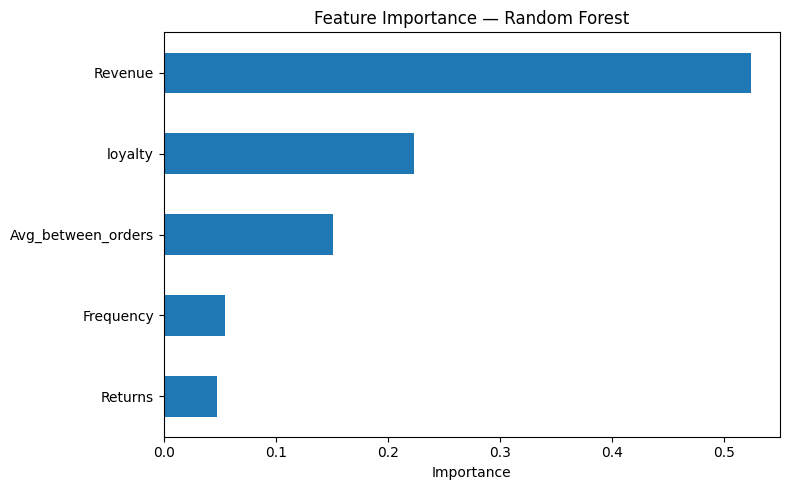

In [7]:
feature_importance = pd.Series(
    model_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind='barh')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()